<a href="https://colab.research.google.com/github/ganeshsembedded-maker/Customer-Churn-Prediction-Logistic-Regression/blob/main/Customer_Churn_Prediction_EDA_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =====================================================
# CUSTOMER CHURN PREDICTION USING LOGISTIC REGRESSION
# =====================================================

# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# ===============================
# 2. LOAD DATASET
# ===============================
train_df = pd.read_excel('/content/train.xlsx')
test_df  = pd.read_excel('/content/test.xlsx')

display(train_df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ===============================
# 3. BASIC DATA CHECKS
# ===============================
print(train_df.info())
print("\nDataset Shape:", train_df.shape)

print("\nMissing Values:\n", train_df.isnull().sum())
print("\nDuplicate Rows:", train_df.duplicated().sum())

train_df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# ===============================
# 4. DATA TYPE FIXING
# ===============================
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
train_df.dropna(subset=['TotalCharges'], inplace=True)

In [7]:
# ===============================
# 5. NUMERICAL & CATEGORICAL SPLIT
# ===============================
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_df.select_dtypes(include='object').columns

print("\nNumerical Columns:", list(numerical_cols))
print("\nCategorical Columns:", list(categorical_cols))


Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [8]:
# ===============================
# 6. FEATURE ENGINEERING
# ===============================
# Drop customerID (not useful for prediction)
train_df = train_df.drop('customerID', axis=1, errors='ignore')

categorical_cols_for_encoding = categorical_cols.drop('customerID', errors='ignore')

# One-hot encoding for categorical features
encoded_cat = pd.get_dummies(train_df[categorical_cols_for_encoding.drop('Churn')], drop_first=True)

# Final processed dataset
final_data = pd.concat([train_df[numerical_cols], encoded_cat], axis=1)

# Target variable
final_data['Churn_Yes'] = train_df['Churn'].map({'No': 0, 'Yes': 1})

display(final_data.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,1
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1


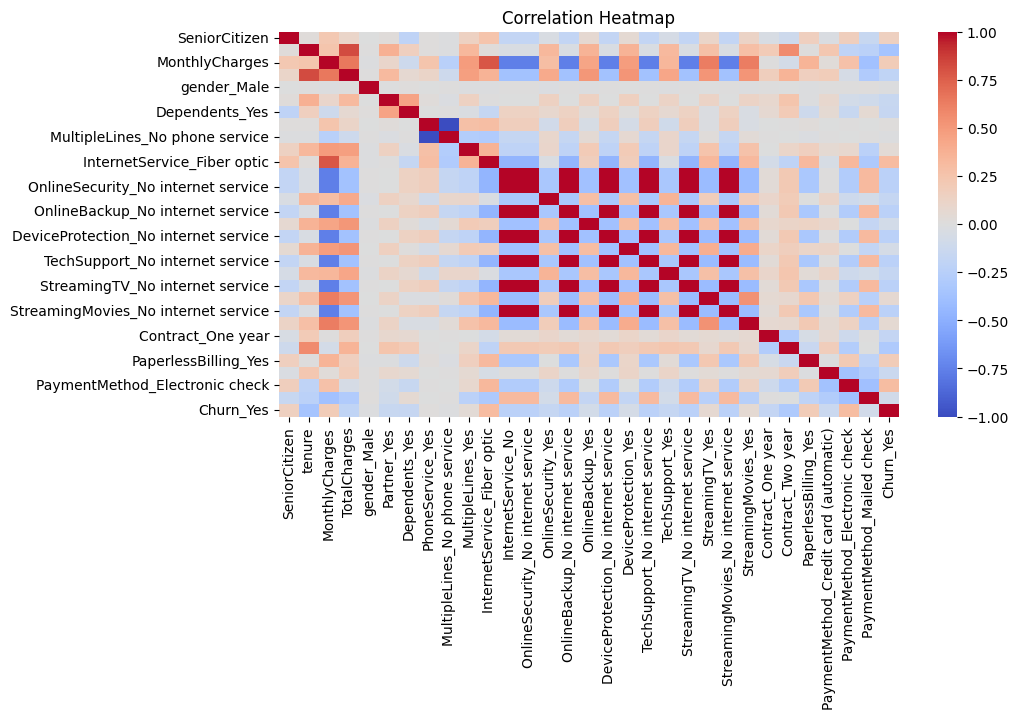


Correlation with Churn:
 Churn_Yes                                1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes      

In [9]:
# ===============================
# 7. CORRELATION ANALYSIS
# ===============================
correlation_matrix = final_data.corr()

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
target_corr = correlation_matrix['Churn_Yes'].sort_values(ascending=False)
print("\nCorrelation with Churn:\n", target_corr)

In [10]:
# ===============================
# 8. FEATURE SELECTION
# ===============================
selected_features = target_corr[abs(target_corr) >= 0.15].index.tolist()
selected_features.remove('Churn_Yes')

print("\nSelected Features:\n", selected_features)


Selected Features:
 ['InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'MonthlyCharges', 'PaperlessBilling_Yes', 'SeniorCitizen', 'Dependents_Yes', 'TechSupport_Yes', 'OnlineSecurity_Yes', 'Contract_One year', 'TotalCharges', 'OnlineSecurity_No internet service', 'StreamingMovies_No internet service', 'OnlineBackup_No internet service', 'InternetService_No', 'TechSupport_No internet service', 'DeviceProtection_No internet service', 'StreamingTV_No internet service', 'Contract_Two year', 'tenure']


In [11]:
# ===============================
# 9. TRAIN-TEST SPLIT
# ===============================
X = final_data[selected_features]
y = final_data['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# ===============================
# 10. MODEL BUILDING
# ===============================
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [13]:
# ===============================
# 11. MODEL EVALUATION
# ===============================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.8017

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



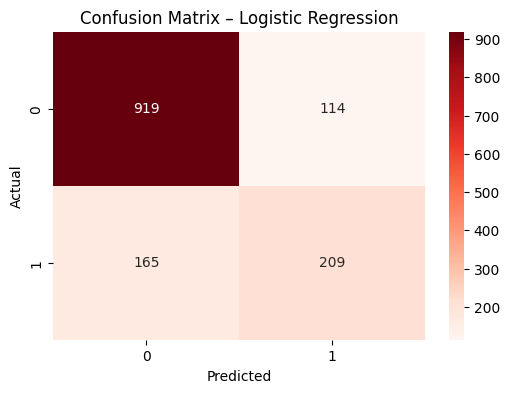


Confusion Matrix:
 [[919 114]
 [165 209]]


In [14]:
# ===============================
# 12. CONFUSION MATRIX
# ===============================
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nConfusion Matrix:\n", conf_matrix)